# CNO burning network

For CNO burning, we need to have both the cold and hot CNO cycles, as well as breakout via the rp-process.  To complete the description, we should also include the pp chains and He burning.

We'll model this network off of MESA's ``cno_extras`` network.

## CNO rates

We can start by building a network using the core nuclei involved in CNO burning.  This will give us all the links (forward and reverse).

In [1]:
import pynucastro as pyna

In [2]:
net = pyna.network_helper(["p", "he4",
                           "c12-13",
                           "n13-15",
                           "o14-18",
                           "f17-19",
                           "ne18-20",
                           "mg22,24"])

We'll remove the C-burning rates

In [3]:
rr = net.get_rate_by_name(["c12(c12,a)ne20",
                           "o16(c12,a)mg24",
                           "ne20(a,c12)c12",
                           "mg24(a,c12)o16"])
net.remove_rates(rr)

```{note}
If we compare to MESA's ``cno_extras`` network, the above construction
contains more reverse rates that MESA ``cno_extras``, including

* $\beta$-decays: 
  ${}^{17}\mathrm{O}(,e^-\nu){}^{18}\mathrm{F}$,
  ${}^{18}\mathrm{O}(,e^-\nu){}^{18}\mathrm{F}$,
  ${}^{18}\mathrm{F}(,e^-\nu){}^{18}\mathrm{Ne}$,
  ${}^{19}\mathrm{F}(,e^-\nu){}^{19}\mathrm{Ne}$,

* $(p,\alpha)$ reactions: 
  ${}^{16}\mathrm{O}(p,\alpha){}^{13}\mathrm{N}$
  ${}^{20}\mathrm{Ne}(p,\alpha){}^{17}\mathrm{F}$,

* $(\gamma,\alpha)$ reactions:
  ${}^{18}\mathrm{F}(\gamma,\alpha){}^{14}\mathrm{N}$,
  ${}^{18}\mathrm{Ne}(\gamma,\alpha){}^{14}\mathrm{O}$,
  ${}^{19}\mathrm{F}(\gamma,\alpha){}^{15}\mathrm{N}$.

It also includes the reverse rates for the $\alpha$-chain as well as
some carbon-burning rates, like ${}^{12}\mathrm{C}({}^{12}\mathrm{C},\alpha){}^{20}\mathrm{Ne}$ and its inverse and ${}^{16}\mathrm{O}({}^{12}\mathrm{C},\alpha){}^{24}\mathrm{Mg}$ and its inverse.
```

## Additional breakout rates

We'll approximate a few rate sequences for breakout, following MESA's ``cno_extras``.  These include:

* ${}^{18}\mathrm{Ne}(\alpha,p){}^{21}\mathrm{Na}(p,\gamma){}^{22}\mathrm{Mg}$
* ${}^{19}\mathrm{Ne}(p,\gamma){}^{20}\mathrm{Na}(p,\gamma){}^{21}\mathrm{Mg}(,e^+\nu){}^{21}\mathrm{Na}(p,\gamma){}^{22}\mathrm{Mg}$
* ${}^{20}\mathrm{Ne}(p,\gamma){}^{21}\mathrm{Na}(p,\gamma){}^{22}\mathrm{Mg}$

The first one is the $(\alpha,p)(p,\gamma)$ counterpart to a rate we already included, so we will replace that with an {py:obj}`ApproximateRate <pynucastro.rates.approximate_rates.ApproximateRate>`.  

The other two can be represented as a {py:obj}`ModifiedRate <pynucastro.rates.modified_rate.ModifiedRate>`, assuming that the first rate in the
sequence is the slowest.

In [4]:
rl = pyna.ReacLibLibrary()

First we'll deal with the ``ApproximateRate``.  We'll remove the $(\alpha,\gamma)$ version and then make the new rate.

In [5]:
rne18ag = rl.get_rate_by_name("ne18(a,g)mg22")
net.remove_rates(rne18ag)

In [6]:
rne18_mg22, _ = pyna.rates.make_ap_pg_rates(rl, "ne18", "mg22", use_detailed_balance=True)
rne18_mg22

Ne18 + He4 ⟶ Mg22 + 𝛾

In [7]:
rne19pg = rl.get_rate_by_name("ne19(p,g)na20")
rne19_mg22 = pyna.ModifiedRate(rne19pg,
                               new_products=[pyna.Nucleus("mg22")],
                               stoichiometry={pyna.Nucleus("p"): 3},
                               description="Ne19(p,γ)Na20(p,γ)Mg21(β+)Na21(p,γ)Mg22")
rne19_mg22

Ne19 + 3 p ⟶ Mg22 + e⁺ + 𝜈

In [8]:
rne20pg = rl.get_rate_by_name("ne20(p,g)na21")
rne20_mg22 = pyna.ModifiedRate(rne20pg,
                               new_products=[pyna.Nucleus("mg22")],
                               stoichiometry={pyna.Nucleus("p"): 2},
                               description="Ne20(p,γ)Na21(p,γ)Mg22")
rne20_mg22

Ne20 + p + p ⟶ Mg22 + 𝛾

In [9]:
net.add_rates([rne18_mg22, rne19_mg22, rne20_mg22])

## PP rates

Finally we will add the same approximation to the pp-chains as done in {doc}`mesa-basic`.

In [10]:
rpp, rpep = rl.get_rate_by_name("p(p,)d")

rppp_he3 = pyna.ModifiedRate(rpp,
                             new_products=[pyna.Nucleus("he3")],
                             stoichiometry={pyna.Nucleus("p"): 3},
                             description="p(p,e⁺ν)d(p,γ)He3",
                             rate_source=rpp.src)

rpepp_he3 = pyna.ModifiedRate(rpep,
                              new_products=[pyna.Nucleus("he3")],
                              stoichiometry={pyna.Nucleus("p"): 3},
                              description="p(pe⁻,ν)d(p,γ)He3",
                              rate_source=rpep.src)

In [11]:
rhe3he3 = rl.get_rate_by_name("he3(he3,pp)he4")
rhe3p = rl.get_rate_by_name("he3(p,)he4")

In [12]:
rhe3he4 = rl.get_rate_by_name("he4(he3,g)be7")
rhe3he4p_2he4 = pyna.ModifiedRate(rhe3he4,
                                  new_reactants=[pyna.Nucleus("he4"),
                                                 pyna.Nucleus("he3"),
                                                 pyna.Nucleus("p")],
                                  new_products=[pyna.Nucleus("he4"),
                                                pyna.Nucleus("he4")],
                                  not_in_ydot_term=[pyna.Nucleus("p")],
                                  description="He4(He3,γ)Be7(e⁻,ν)Li7(p,α)He4")

In [13]:
net.add_rates([rppp_he3, rpepp_he3,
               rhe3he3, rhe3p, rhe3he4p_2he4])

## Final network

Our final network appears as

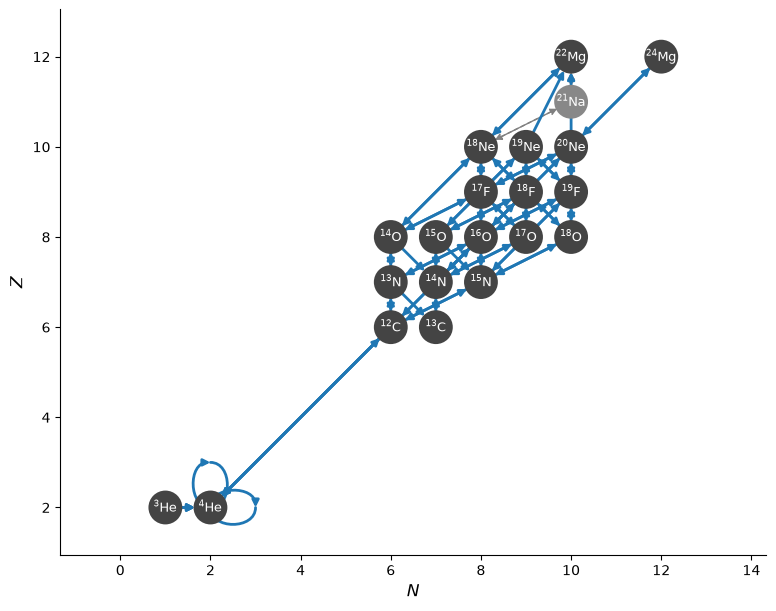

In [14]:
fig = net.plot(node_size=500, node_font_size="9")

In [15]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 21
  approximated-out nuclei: 1
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 84

  rates explicitly connecting nuclei: 74
  hidden rates: 10

  reaclib rates: 40
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 8
  approximate rates: 1
  derived rates: 30
  branched rates: 0
  modified rates: 5
  custom rates: 0
